# Aegis Threat Classifier - Performance & Metrics Analysis
This notebook loads the trained **CNN-BiLSTM-Transformer (BERT)** threat detection model and visualizes its performance across individual validation datasets (CICIDS2017, UNSW-NB15, Synthetic) and the Combined dataset.

### Visualizations:
1. **Class-wise Precision, Recall, and F1-Scores**
2. **Confusion Matrices (Heatmaps)**
3. **Overall Accuracy Comparisons**

In [1]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Add src/ to python path so we can import model definitions
import sys
sys.path.append(os.path.abspath('src'))
from model import PayloadCNNBiLSTMBERT

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Preprocessing Components & Model Weights
We load the fit `StandardScaler`, `LabelEncoder` (for labels and protocols), and the trained PyTorch state dictionary.

In [2]:
MODEL_DIR = 'models'

label_encoder = joblib.load(os.path.join(MODEL_DIR, 'label_encoder.joblib'))
protocol_encoder = joblib.load(os.path.join(MODEL_DIR, 'protocol_encoder.joblib'))
scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.joblib'))

num_classes = len(label_encoder.classes_)
print(f"Loaded classes: {list(label_encoder.classes_)}")

# Initialize model structure and load saved weights
model = PayloadCNNBiLSTMBERT(num_classes=num_classes).to(device)
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'model.pth'), map_location=device, weights_only=True))
model.eval()
print("Model structure loaded and weights restored successfully.")

Loaded classes: ['BENIGN', 'Bot', 'Brute Force', 'DoS', 'Infiltration', 'PortScan']
Model structure loaded and weights restored successfully.


## 2. Memory-Efficient Data Loading Function
Reads packet payload bytes and network metadata from split validation files.

In [3]:
def load_validation_data(csv_path):
    if not os.path.exists(csv_path):
        print(f"File {csv_path} does not exist. Skipping...")
        return None, None, None
        
    payload_cols = [f'payload_byte_{i}' for i in range(1, 1501)]
    meta_cols = ['ttl', 'total_len', 't_delta', 'protocol']
    
    dtypes = {f'payload_byte_{i}': np.uint8 for i in range(1, 1501)}
    dtypes['ttl'] = np.uint16
    dtypes['total_len'] = np.uint32
    dtypes['protocol'] = str
    dtypes['t_delta'] = np.float32
    dtypes['label'] = str
    
    chunksize = 100000
    payload_list = []
    meta_list = []
    labels_list = []
    
    for chunk in pd.read_csv(csv_path, dtype=dtypes, chunksize=chunksize):
        payload_list.append(chunk[payload_cols].values)
        meta_list.append(chunk[meta_cols])
        labels_list.append(chunk['label'].values)
        
    payloads = np.concatenate(payload_list, axis=0)
    meta_df = pd.concat(meta_list, ignore_index=True)
    labels = np.concatenate(labels_list, axis=0)
    
    return payloads, meta_df, labels

## 3. Evaluation & Visualization Function
Preprocesses data, predicts using PyTorch, calculates performance metrics, and plots confusion matrices as a Seaborn Heatmap.

In [4]:
def evaluate_and_plot(csv_path, name, batch_size=256):
    payloads, meta_df, labels_str = load_validation_data(csv_path)
    if payloads is None:
        return
        
    # 1. Transform Labels
    y_true = label_encoder.transform(labels_str)
    
    # 2. Transform Protocols (handle unseen)
    val_protos = meta_df['protocol'].astype(str).str.strip().str.lower().fillna('unknown')
    val_protos = val_protos.map(lambda s: s if s in protocol_encoder.classes_ else 'unknown')
    if 'unknown' not in protocol_encoder.classes_:
        protocol_encoder.classes_ = np.append(protocol_encoder.classes_, 'unknown')
    meta_df['protocol_encoded'] = protocol_encoder.transform(val_protos)
    
    # 3. Transform Metadata
    meta_cols = ['ttl', 'total_len', 't_delta', 'protocol_encoded']
    X_meta = scaler.transform(meta_df[meta_cols].values.astype(np.float32))
    
    # Create Dataloader
    dataset = TensorDataset(
        torch.tensor(payloads, dtype=torch.uint8),
        torch.tensor(X_meta, dtype=torch.float32),
        torch.tensor(y_true, dtype=torch.long)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    # Predict
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_payloads, batch_metas, batch_labels in loader:
            batch_payloads = batch_payloads.to(device)
            batch_metas = batch_metas.to(device)
            
            outputs = model(batch_payloads, batch_metas)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(batch_labels.numpy())
            
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # 4. Generate Reports
    print(f"\n=========================================")
    print(f" Classification Report: {name}")
    print(f"=========================================")
    report = classification_report(
        all_targets, 
        all_preds, 
        target_names=label_encoder.classes_,
        labels=range(num_classes),
        zero_division=0
    )
    print(report)
    
    # 5. Plot Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        cbar=True
    )
    plt.title(f"Confusion Matrix: {name}", fontsize=14, pad=15)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Free memory
    del payloads, meta_df, dataset, loader, all_preds, all_targets, cm
    gc.collect()

## 4. Run Analysis & Plot Stats

### A. Combined Validation Set
Evaluate on all validation sources combined (CICIDS + UNSW + Synthetic).


 Classification Report: Combined Validation Dataset
              precision    recall  f1-score   support

      BENIGN       0.98      0.98      0.98    155244
         Bot       0.64      0.99      0.78      3056
 Brute Force       0.97      0.98      0.98     43189
         DoS       1.00      0.99      0.99    339826
Infiltration       0.98      0.95      0.97     79388
    PortScan       0.57      0.94      0.71      5357

    accuracy                           0.98    626060
   macro avg       0.86      0.97      0.90    626060
weighted avg       0.99      0.98      0.98    626060



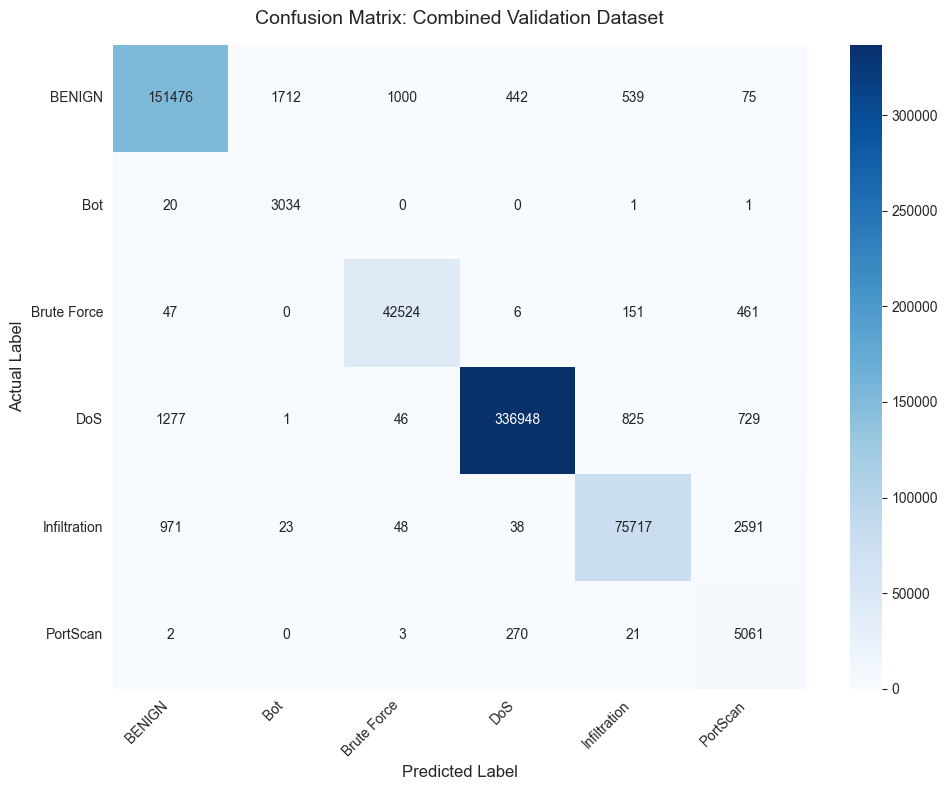

In [5]:
evaluate_and_plot('data/val/combined_val.csv', 'Combined Validation Dataset')

### B. Individual Validation Sets
Compare the models' performance individually on public benchmarks vs synthetic samples.


 Classification Report: CICIDS2017 Dataset
              precision    recall  f1-score   support

      BENIGN       1.00      0.98      0.99    144844
         Bot       0.37      0.98      0.53      1018
 Brute Force       0.98      1.00      0.99     36705
         DoS       1.00      1.00      1.00    328467
Infiltration       0.99      1.00      0.99     52739
    PortScan       0.25      0.18      0.21       332

    accuracy                           0.99    564105
   macro avg       0.76      0.85      0.78    564105
weighted avg       0.99      0.99      0.99    564105



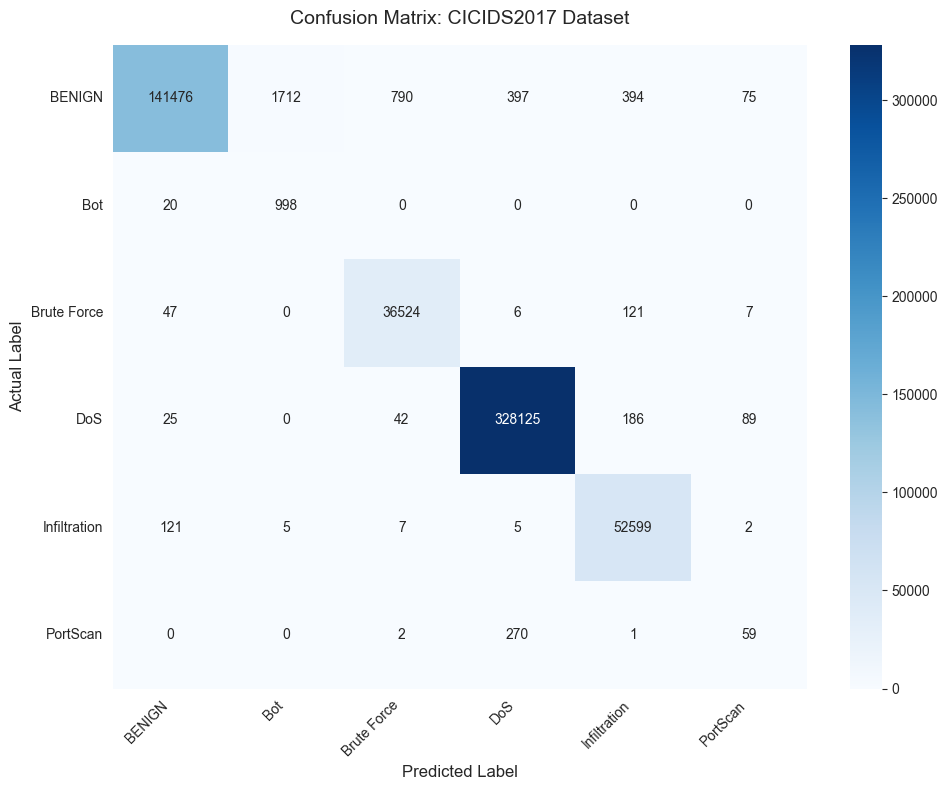


 Classification Report: UNSW-NB15 Dataset
              precision    recall  f1-score   support

      BENIGN       0.90      0.95      0.92      8400
         Bot       0.65      0.95      0.77        38
 Brute Force       0.00      0.00      0.00       484
         DoS       0.09      0.01      0.01      1359
Infiltration       0.95      0.81      0.87     18649
    PortScan       0.45      0.99      0.62      3025

    accuracy                           0.82     31955
   macro avg       0.51      0.62      0.53     31955
weighted avg       0.84      0.82      0.81     31955



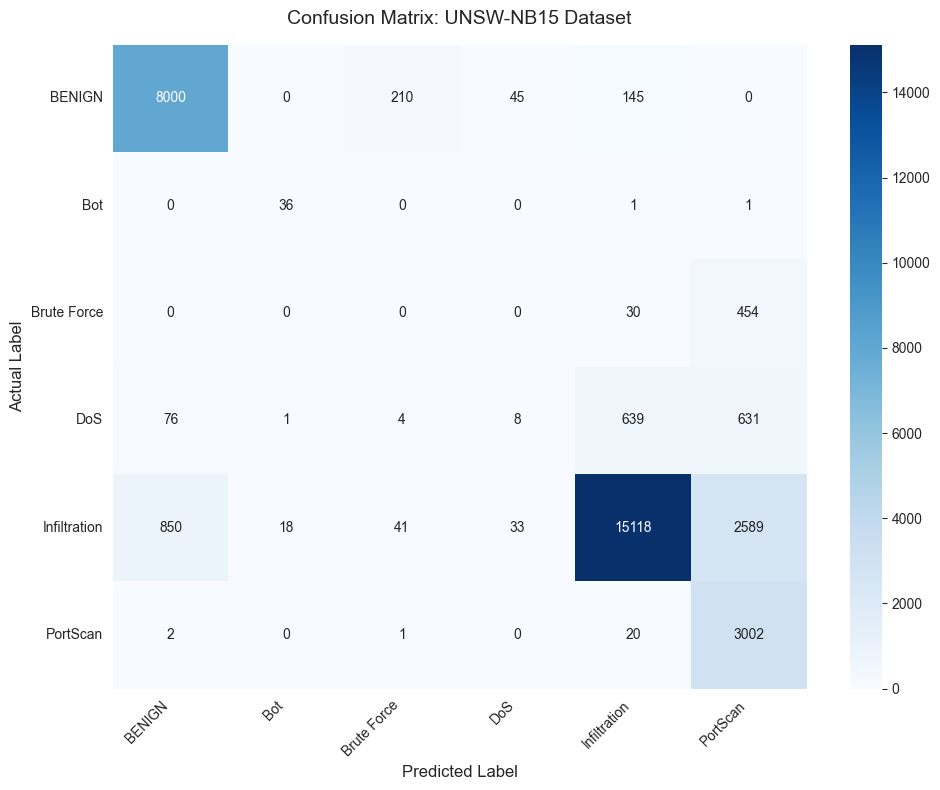


 Classification Report: Synthetic Threats Dataset
              precision    recall  f1-score   support

      BENIGN       0.63      1.00      0.77      2000
         Bot       1.00      1.00      1.00      2000
 Brute Force       1.00      1.00      1.00      6000
         DoS       1.00      0.88      0.94     10000
Infiltration       1.00      1.00      1.00      8000
    PortScan       1.00      1.00      1.00      2000

    accuracy                           0.96     30000
   macro avg       0.94      0.98      0.95     30000
weighted avg       0.98      0.96      0.96     30000



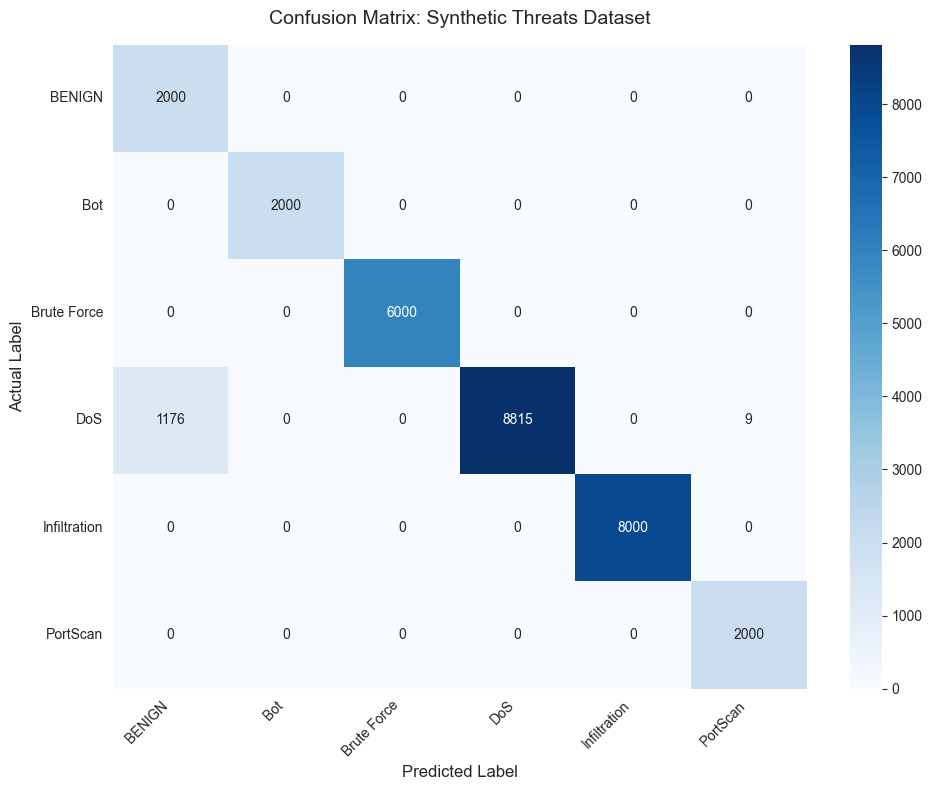

In [6]:
# CICIDS2017 Validation Set
evaluate_and_plot('data/val/cicids_val.csv', 'CICIDS2017 Dataset')

# UNSW-NB15 Validation Set
evaluate_and_plot('data/val/unsw_val.csv', 'UNSW-NB15 Dataset')

# Synthetic Threats Validation Set
evaluate_and_plot('data/val/synthetic_val.csv', 'Synthetic Threats Dataset')